In [3]:
# First, we import our libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.svm import SVC, SVR
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.impute import SimpleImputer
from sklearn.impute import KNNImputer
from sklearn.pipeline import Pipeline

In [4]:
loan  = pd.read_csv('data/loan_data.csv')
loan

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [3]:
loan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [4]:
loan.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [5]:
loan.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [6]:
x = loan.drop(columns=["Loan_ID","Loan_Status"])
y = loan["Loan_Status"]

In [7]:
x

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban
...,...,...,...,...,...,...,...,...,...,...,...
609,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural
610,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural
611,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban
612,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban


In [8]:
y.head()

0    Y
1    N
2    Y
3    Y
4    Y
Name: Loan_Status, dtype: object

## ENCODING THE DATA

In [13]:
loan["Dependents"].value_counts()

Dependents
0     345
1     102
2     101
3+     51
Name: count, dtype: int64

In [9]:
x["Gender"] = x["Gender"].map({'Male':0, 'Female':1})

In [10]:
x["Married"] = x["Married"].map({'No':0, 'Yes':1})

In [11]:
x["Education"] = x["Education"].map({'Graduate':1, 'Not_Graduate':0})

In [14]:
x["Dependents"] = x["Dependents"].map({'0':0,'1':1,'2':2,'3+':3})

In [15]:
x["Self_Employed"] = x["Self_Employed"].map({'No':0, 'Yes':1})

In [16]:
x["Property_Area"] = x["Property_Area"].map({'Urban':0, 'Rural':1, 'Semiurban':2})

In [17]:
imputer = SimpleImputer(strategy='mean')
x['LoanAmount'] = imputer.fit_transform(x['LoanAmount'].to_numpy().reshape(-1,1))

In [19]:
imputer = SimpleImputer(strategy='mean')
x['Loan_Amount_Term'] = imputer.fit_transform(x['Loan_Amount_Term'].to_numpy().reshape(-1,1))

In [20]:
x.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,0.0,0.0,0.0,1.0,0.0,5849,0.0,146.412162,360.0,1.0,0
1,0.0,1.0,1.0,1.0,0.0,4583,1508.0,128.000000,360.0,1.0,1
2,0.0,1.0,0.0,1.0,1.0,3000,0.0,66.000000,360.0,1.0,0
3,0.0,1.0,0.0,NaN,0.0,2583,2358.0,120.000000,360.0,1.0,0
4,0.0,0.0,0.0,1.0,0.0,6000,0.0,141.000000,360.0,1.0,0


In [21]:
x["Education"] = x["Education"].fillna(x["Education"].mode()[0])

In [29]:
x["Dependents"] = x["Dependents"].fillna(x["Dependents"].mode()[0])

In [22]:
x["Self_Employed"] = x["Self_Employed"].fillna(x["Self_Employed"].mode()[0])

In [23]:
x["Gender"] = x["Gender"].fillna(x["Gender"].mode()[0])

In [24]:
x["Married"] = x["Married"].fillna(x["Married"].mode()[0])


In [26]:
x["Credit_History"] = x["Credit_History"].fillna(x["Credit_History"].mode()[0])

In [30]:
x.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,0.0,0.0,0.0,1.0,0.0,5849,0.0,146.412162,360.0,1.0,0
1,0.0,1.0,1.0,1.0,0.0,4583,1508.0,128.000000,360.0,1.0,1
2,0.0,1.0,0.0,1.0,1.0,3000,0.0,66.000000,360.0,1.0,0
3,0.0,1.0,0.0,1.0,0.0,2583,2358.0,120.000000,360.0,1.0,0
4,0.0,0.0,0.0,1.0,0.0,6000,0.0,141.000000,360.0,1.0,0


In [31]:
x.isnull().sum()

Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
dtype: int64

In [32]:
x_train,x_test,y_train,y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [33]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

## USING LOGISTIC REGRESSION

In [34]:
model = LogisticRegression()
model.fit(x_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [35]:
y_pred = model.predict(x_test_scaled)
y_accuracy = accuracy_score(
    y_test,
    y_pred
)
print("LOGISTIC REGRESSION CLASSIFIER:", y_accuracy)

LOGISTIC REGRESSION CLASSIFIER: 0.8617886178861789


In [36]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           N       0.96      0.58      0.72        38
           Y       0.84      0.99      0.91        85

    accuracy                           0.86       123
   macro avg       0.90      0.78      0.81       123
weighted avg       0.88      0.86      0.85       123



## USING PIPELINE FOR LOGISTIC REGRESSION

In [39]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression())
])

pipeline.fit(x_train, y_train)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [41]:
y_pred = pipeline.predict(x_test)
y_accuracy = accuracy_score(y_test,y_pred)
print("Pipeline_Accuracy:", y_accuracy)

Pipeline_Accuracy: 0.8617886178861789


In [42]:
log_cm = confusion_matrix(y_test,y_pred)
print(log_cm)

[[22 16]
 [ 1 84]]


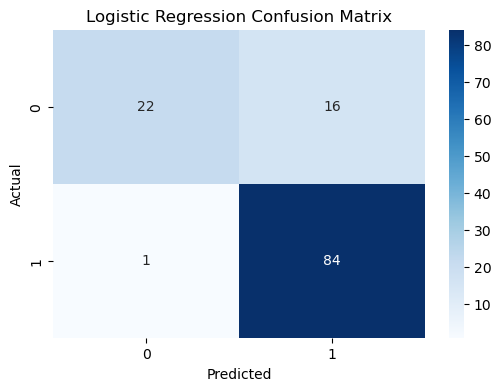

In [43]:
import seaborn as sns
# Ensure the title matches your actual variable (e.g., forest_cm)
plt.figure(figsize=(6, 4))
sns.heatmap(log_cm, annot=True, fmt="d", cmap="Blues", cbar=True)
# Add labels and title
plt.title("Logistic Regression Confusion Matrix") # Updated to match variable
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## USING DECISION TREEE

In [44]:
dec_model = DecisionTreeClassifier()
dec_model.fit(x_train_scaled, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [45]:
y_pred = dec_model.predict(x_test_scaled)
y_accuracy = accuracy_score(
    y_test,
    y_pred
)
print("DECISION TREE CLASSIFIER:", y_accuracy)

DECISION TREE CLASSIFIER: 0.7479674796747967


In [46]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           N       0.58      0.66      0.62        38
           Y       0.84      0.79      0.81        85

    accuracy                           0.75       123
   macro avg       0.71      0.72      0.71       123
weighted avg       0.76      0.75      0.75       123



## USING PIPELINE FOR DECISION TREE CLASSIFIER

In [48]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', DecisionTreeClassifier())
])

pipeline.fit(x_train, y_train)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2


In [49]:
y_pred = pipeline.predict(x_test)
y_accuracy = accuracy_score(y_test,y_pred)
print("Pipeline_Accuracy:", y_accuracy)

Pipeline_Accuracy: 0.7479674796747967


In [50]:
tree_cm = confusion_matrix(y_test,y_pred)
print(tree_cm)

[[24 14]
 [17 68]]
